# 01. TPE Disk Tracking — StarDist

**Pipeline step 1 of 3** — detects photoelastic disks in each frame and links them into trajectories, then computes continuous rotation angles from UV images.

## Inputs
- Green-channel fluorescence images (`Ic_*.png`) — for disk detection
- UV/blue-channel images (`Ic_*.png`, alternate index) — for orientation tracking
- PE images (`Ib_*.png`) — used for inspection only

## Outputs
- `<EXP_FOLDER>.pkl` — trajectory dataframe with columns:
  `frame, x, y, rpx, particle, boundary, angle`

## Workflow
1. Detect disks with StarDist2D → filter by area & eccentricity
2. Link detections into trajectories with Trackpy, interpolate gaps
3. Compute continuous rotation angles via PCA on UV images
4. Save trajectory to disk

### Imports

In [1]:
from __future__ import print_function, unicode_literals, absolute_import, division
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import cv2
import os
import sys
from skimage import measure
from csbdeep.utils import normalize
from stardist.models import StarDist2D

### Utility functions

In [2]:
def max_num(img_dir, exp_folder):
    """Return the highest image index found in the experiment folder (Ic_*.png)."""
    files = os.listdir(os.path.join(img_dir, exp_folder))
    frame_numbers = [int(f.split('_')[1].split('.')[0]) for f in files
                     if f.startswith('Ic_') and f.endswith('.png')]
    return np.max(frame_numbers) if frame_numbers else 0


def camera_align(I):
    """Apply perspective correction (calibrated 2026-01-22)."""
    H = np.array([[ 1.00847109e+00,  1.96903443e-02, -1.54332807e+01],
                  [-1.68872158e-02,  1.01773292e+00, -2.19123604e+01],
                  [-3.15305787e-06,  1.27538375e-06,  1.00000000e+00]])
    height, width = I.shape[:2]
    return cv2.warpPerspective(I, H, (width, height))


def PCA(I):
    """Return the principal direction vector and R² of a binary image."""
    y, x = np.nonzero(I)
    data = np.column_stack((x, y))
    centered = data - np.mean(data, axis=0)
    _, S, Vt = np.linalg.svd(centered)
    direction = Vt[0]
    R2 = S[0]**2 / (S[0]**2 + S[1]**2)
    return direction, R2


def interpolate_pos_angle(df):
    """Linearly interpolate x/y for frames where a particle was not detected."""
    new_rows = []
    total_missing = 0

    for pid, particle_data in df.groupby('particle'):
        particle_data = particle_data.set_index('frame').sort_index()
        frames = particle_data.index.to_numpy()
        if len(frames) == 0:
            continue

        missing = sorted(set(range(frames[0], frames[-1] + 1)) - set(frames))
        if not missing:
            continue

        total_missing += len(missing)
        placeholders = pd.DataFrame(index=missing, columns=particle_data.columns)
        placeholders['particle'] = pid
        placeholders.index.name = 'frame'

        combined = pd.concat([particle_data, placeholders]).sort_index()
        combined[['x', 'y']] = combined[['x', 'y']].interpolate(method='linear', limit_direction='both')
        for col in ['rpx']:
            combined[col] = combined[col].ffill().bfill()

        combined = combined.reset_index()
        new_rows.append(combined[combined['frame'].isin(missing)])

    if new_rows:
        df = pd.concat([df, *new_rows], ignore_index=True)

    df = df.sort_values(['particle', 'frame']).reset_index(drop=True)
    print(f'Interpolated {total_missing} missing positions.')
    return df


def crop_circle_with_mask_float(img):
    """Zero out pixels outside the inscribed circle of a square float image."""
    h, w = img.shape[:2]
    center = (w // 2, h // 2)
    radius = min(center[0], center[1])
    Y, X, C = np.ogrid[:h, :w, :3]
    mask = (X - center[0])**2 + (Y - center[1])**2 <= radius**2
    return img * mask


def generate_cropped_batch(f, img):
    """Crop, resize, and normalise one image patch per particle row in f."""
    batch = np.empty((len(f), 128, 128, 3), dtype=np.float32)
    h, w = img.shape[:2]
    for i in range(len(f)):
        row = f.iloc[i]
        x, y, r = int(np.around(row['x'])), int(np.around(row['y'])), int(row['rpx'])
        y1, y2 = max(0, y - r), min(h, y + r)
        x1, x2 = max(0, x - r), min(w, x + r)
        img_crop = img[y1:y2, x1:x2]
        img_crop = cv2.resize(img_crop, (128, 128), interpolation=cv2.INTER_AREA)
        img_crop = cv2.blur(img_crop, ksize=(3, 3)).astype(np.float32) / 255
        img_crop = crop_circle_with_mask_float(img_crop)
        batch[i] = img_crop
    return batch


def compute_continuous_angles(df):
    """Accumulate unwrapped rotation angles across frames for each particle.

    Handles the π-ambiguity of PCA orientation vectors: at each step the branch
    (raw_angle or raw_angle ± π) closest to the previous accumulated direction is
    chosen.  Operates on numpy arrays to avoid per-row pandas overhead.
    """
    df = df.sort_values(['particle', 'frame']).copy()
    df['angle'] = np.nan

    raw     = np.arctan2(df['dir_y'].to_numpy(dtype=float),
                         df['dir_x'].to_numpy(dtype=float))
    pids    = df['particle'].to_numpy()
    angle_out = np.full(len(df), np.nan)

    prev_raw: dict = {}
    prev_acc: dict = {}

    for k in range(len(df)):
        r = raw[k]
        if np.isnan(r):
            continue
        pid = pids[k]
        if pid not in prev_acc:
            prev_acc[pid] = r
            prev_raw[pid] = r
        else:
            pr   = prev_raw[pid]
            opt2 = r + np.pi if r < 0 else r - np.pi
            d1   = np.angle(np.exp(1j * (r    - pr)))
            d2   = np.angle(np.exp(1j * (opt2 - pr)))
            prev_acc[pid] += d1 if abs(d1) < abs(d2) else d2
            prev_raw[pid]  = r
        angle_out[k] = prev_acc[pid]

    df['angle'] = angle_out
    return df


def draw_particle_orientation(
    img: np.ndarray,
    df: pd.DataFrame,
    x_col: str = 'x',
    y_col: str = 'y',
    angle_col: str = 'angle',
    linewidth: int = 1,
    linecolor: str = 'r',
    circle_color: str = 'r',
    show: bool = False
) -> np.ndarray:
    """Overlay orientation lines and circles on the image. Returns BGR array."""
    img_draw = img.copy()
    if img_draw.ndim == 2:
        img_draw = cv2.cvtColor(img_draw, cv2.COLOR_GRAY2BGR)

    # Keep only rows with a valid angle
    df_plot = df[df[angle_col].notnull()].copy()

    for idx, row in df_plot.iterrows():
        xc    = float(row[x_col])
        yc    = float(row[y_col])
        theta = float(row[angle_col])
        frame = int(row['frame']) if 'frame' in row else None
        half  = float(row['rpx'])

        dx = np.cos(theta) * half
        dy = np.sin(theta) * half

        # Draw symmetric orientation line
        pt1 = (int(round(xc - dx)), int(round(yc - dy)))
        pt2 = (int(round(xc + dx)), int(round(yc + dy)))
        color = np.array(mcolors.to_rgb(linecolor)) * 255
        cv2.line(img_draw, pt1, pt2, color, thickness=linewidth, lineType=cv2.LINE_AA)
        cv2.circle(img_draw, (int(round(xc)), int(round(yc))), int(row['rpx']),
                   np.array(mcolors.to_rgb(circle_color)) * 255,
                   thickness=linewidth, lineType=cv2.LINE_AA)

    if show:
        # Convert BGR to RGB for matplotlib display
        plt.figure(figsize=(10, 10))
        plt.imshow(cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        title = 'Orientation overlay'
        if frame is not None:
            title += f' (frame {frame})'
        plt.title(title)
        plt.show()

    return img_draw


### Parameters — edit here before running

In [3]:
IMG_DIR    = r'N:\PROJ_TPE'
EXP_FOLDER = 'TPE_20260122A01_N=265x2_5e-4rps_10fps_steady_2000frames'
PKL_DIR    = r'M:\Archive\Proj_TPE\Disk_traj_files'

roi = (250, 1200, 0, 2000)  # (y_min, y_max, x_min, x_max)

# Derived values
max_index   = int(max_num(IMG_DIR, EXP_FOLDER))
max_frame   = max_index // 2
pickle_path = os.path.join(PKL_DIR, EXP_FOLDER)

print(f"Max image index: {max_index}")
print(f"Max frame:       {max_frame}")

Max image index: 4001
Max frame:       2000


### Load models

In [4]:
MODEL_DIR = os.path.join(os.getcwd(), 'models')
model_name = "stardist_09221229"
model = StarDist2D(None, name=model_name, basedir=MODEL_DIR)

Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.724202, nms_thresh=0.3.


### Load images and predict

In [5]:
axis_norm = (0,1)   # normalize channels independentl
import gc
import tensorflow as tf

records = [] #empty list to store results temporarily
k_list = np.zeros(max_frame+1, dtype=int)

#for frame in range(1, max_frame + 1):
for frame in range(1, 10):
    # Try both possible k values
    k1 = frame * 2 + 1
    k2 = frame * 2
    
    # Load both images
    path1 = os.path.join(IMG_DIR, EXP_FOLDER, f'Ic_{k1:d}.png')
    path2 = os.path.join(IMG_DIR, EXP_FOLDER, f'Ic_{k2:d}.png')
    
    I1 = camera_align(cv2.flip(cv2.imread(path1), 1))
    I2 = camera_align(cv2.flip(cv2.imread(path2), 1))
    
    # Compare intensity sums on green channel
    sum1 = I1[:,:,1].sum()
    sum2 = I2[:,:,1].sum()
    
    # Choose the brighter one
    if sum1 > sum2:
        I = I1
        k = k1
    else:
        I = I2
        k = k2
    
    sys.stdout.write(f"\rProcessing frame: {frame}, k = {k}")
    sys.stdout.flush()
    
    k_list[frame] = k

    Ig = I[roi[0]:roi[1], roi[2]:roi[3], 1] #GREEN CHANNEL 

    X = normalize(Ig,1,99.8,axis=axis_norm)
    #PREDICT 
    mask, detail = model.predict_instances(X, n_tiles=model._guess_n_tiles(X), show_tile_progress=False)

    # Compute properties
    props = measure.regionprops(mask)

    # Create a list of dicts
    for region in props:
        y, x = region.centroid  # note: (row, col) = (y, x)
        records.append({
            "frame": frame,
            "x": x,
            "y": y,
            "area": region.area,
            "ecc": region.eccentricity
        })
    
    # Delete large variables explicitly
    del I, Ig, X, mask, detail, props
    
    # Clear memory periodically
    if frame % 100 == 0:
        gc.collect()
        tf.keras.backend.clear_session()

df = pd.DataFrame.from_records(records)

Processing frame: 9, k = 19

### Filter Dataframe

Text(0.5, 0.98, 'Filtered disks')

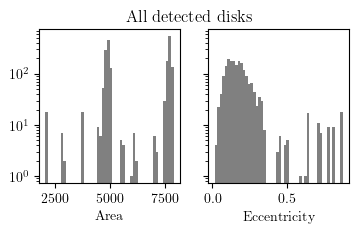

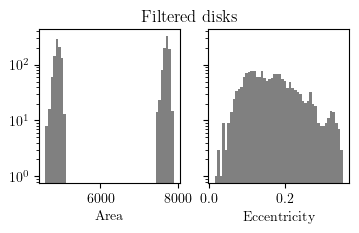

In [6]:
# Find your Times New Roman font file path
times_new_roman_path = r"C:\Windows\Fonts\times.ttf"
from matplotlib import font_manager
times_new_roman_font = font_manager.FontProperties(fname=times_new_roman_path)
plt.rcParams['font.family'] = times_new_roman_font.get_name()
plt.rcParams['figure.dpi'] = 100
plt.rcParams['text.usetex'] = True
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Before filter
#plot area histogram to inspect
fig, axes = plt.subplots(1, 2, figsize=(4, 2), sharey=True)
axes[0].hist(df['area'], bins=50, color='gray')
axes[0].set_yscale('log')
axes[0].set_xlabel('Area')

#plot eccentricity histogram to inspect
axes[1].hist(df['ecc'], bins=50, color='gray')
axes[1].set_yscale('log')
axes[1].set_xlabel('Eccentricity')
fig.suptitle('All detected disks')

################################## Filter Dataframe ################################################
df_filtered = df[(df["x"] < 1860)&(df["x"] > 100)&(df["y"] > 50)] #trim off boundary 
df_filtered = df_filtered[df_filtered["ecc"] < 0.6] #filter eccentricity #ecc filter changed to 0.6 20250923
df_filtered.loc[:,'rpx'] = 46 #add radius column
df_filtered.loc[df_filtered['area']<6000, 'rpx'] = 37

#####################################################################################################

#After filter
#plot area histogram to inspect
fig2, axes2 = plt.subplots(1, 2, figsize=(4, 2), sharey=True)
axes2[0].hist(df_filtered['area'], bins=50, color='gray')
axes2[0].set_yscale('log')
axes2[0].set_xlabel('Area')

#plot eccentricity histogram to inspect
axes2[1].hist(df_filtered['ecc'], bins=50, color='gray')
axes2[1].set_yscale('log')
axes2[1].set_xlabel('Eccentricity')
fig2.suptitle('Filtered disks')


### Inspect detection in a random frame

Randomly selected frame: 8


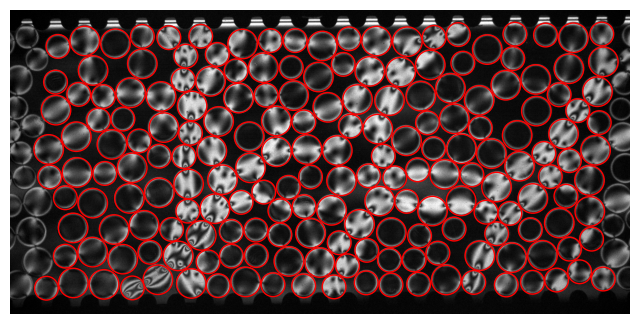

In [ ]:
from matplotlib.patches import Circle

frame = np.random.choice(df_filtered['frame'].unique())
print(f"Randomly selected frame: {frame}")

f = df_filtered[(df_filtered.frame == frame)]
path = os.path.join(IMG_DIR, EXP_FOLDER, f'Ib_{frame+1}.png')
test_img = cv2.imread(path)[roi[0]:roi[1], roi[2]:roi[3], 0]

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(test_img, cmap = 'gray')  # Your raw image

for _, row in f.iterrows():
    circ = Circle((row["x"], row["y"]), row["rpx"], edgecolor='red', facecolor='none', linewidth=1)
    ax.add_patch(circ)
plt.axis('off')
plt.show()


### Link coordinates into trajectory

In [8]:
import trackpy as tp

# link particles
F_linked = tp.link(df_filtered, search_range=30, memory=10)
F_linked = interpolate_pos_angle(F_linked)

# Mark boundary particles
F_linked['boundary'] = (F_linked.x < 200) | (F_linked.x > 1786) | (F_linked.y < 120) | (F_linked.y > 820)

# Change radius to mode value for each particle
F_linked['rpx'] = F_linked.groupby('particle')['rpx'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else x)


Frame 9: 191 trajectories present.
Interpolated 0 missing positions.


### Find rotation angles

incorporated from TPE_rotation_angle_finder

In [10]:
records_rot = []  # collect (original_index, dir_x, dir_y, angle_R2) tuples
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
R2_list = []

# Initialize direction columns if they don't exist
if 'dir_x' not in F_linked.columns:
    F_linked['dir_x'] = np.nan
if 'dir_y' not in F_linked.columns:
    F_linked['dir_y'] = np.nan

# Pre-group 
grouped_linked = F_linked.groupby('frame')

#for frame in range(1, max_frame + 1):
for frame in range(1, max(F_linked['frame']) + 1):
    # Use the k value that was NOT chosen in the previous cell
    k1, k2 = frame * 2 + 1, frame * 2
    k = k2 if k_list[frame] == k1 else k1

    sys.stdout.write(f"\rProcessing frame: {frame}, k = {k}")
    sys.stdout.flush()

    path = os.path.join(IMG_DIR, EXP_FOLDER, f'Ic_{k:d}.png')
    I = camera_align(cv2.flip(cv2.imread(path), 1))
    I = I[roi[0]:roi[1], roi[2]:roi[3], 0]  # BLUE CHANNEL

    if frame not in grouped_linked.groups:
        continue
    f = grouped_linked.get_group(frame)

    for id, row in f.iterrows():
        yc, xc = row['y'], row['x']
        roi_half_length = row['rpx'] * 0.6  # length of the bar
        y1, y2 = int(yc - roi_half_length), int(yc + roi_half_length)
        x1, x2 = int(xc - roi_half_length), int(xc + roi_half_length)
        uv_roi = I[y1:y2, x1:x2]
        if uv_roi.size > 0 and uv_roi.shape[0] > 0 and uv_roi.shape[1] > 0:
            uv_roi = cv2.GaussianBlur(uv_roi, (5, 5), 1)
            _, binarize = cv2.threshold(uv_roi, 0, 255, cv2.THRESH_OTSU)
            binarize = cv2.morphologyEx(binarize, cv2.MORPH_ERODE, kernel, iterations=2)
            direction, R2 = PCA(binarize)  # find principal direction vector
            records_rot.append((id, direction[0], direction[1], R2))
            R2_list.append(R2)

# Bulk-assign all rotation results in one shot (avoids repeated F_linked.loc[] writes)
if records_rot:
    rot_df = pd.DataFrame(records_rot,
                          columns=['_idx', 'dir_x', 'dir_y', 'angle_R2']
                          ).set_index('_idx')
    F_linked.update(rot_df)

F_linked = compute_continuous_angles(F_linked)
F_linked.drop(['dir_x', 'dir_y'], axis=1, inplace=True)


Processing frame: 9, k = 18

4 2


(np.float64(-0.5), np.float64(1935.5), np.float64(949.5), np.float64(-0.5))

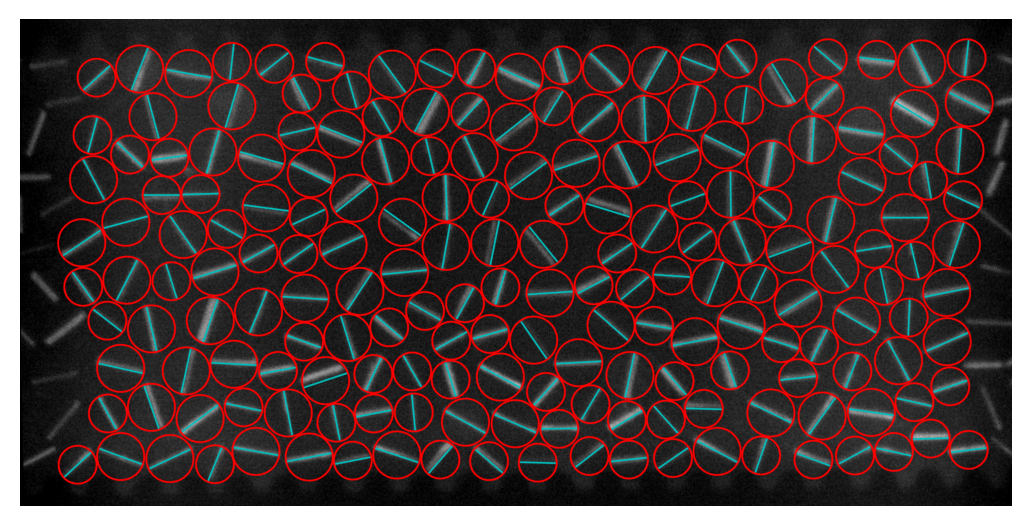

In [11]:
plt.rcParams['figure.dpi'] = 200

frame = 2
k1 = frame * 2 + 1
k2 = frame * 2
k_chosen = k_list[frame]

if k_chosen == k1:
    k = k2
else:
    k = k1

print(k, frame)
path = os.path.join(IMG_DIR, EXP_FOLDER, f'Ic_{k1+1:d}.png')
I = camera_align(cv2.flip(cv2.imread(path), 1))
I = I[roi[0]:roi[1], roi[2]:roi[3], 0] #BLUE CHANNEL 
if I.ndim == 2:  
    I = cv2.cvtColor(I, cv2.COLOR_GRAY2BGR)

    
res = draw_particle_orientation(I.copy(),F_linked[(F_linked.frame==frame)], show = False, linecolor='c', linewidth=2)
plt.imshow(res)
plt.axis('off')

### save to disk

In [60]:
F_linked.to_pickle(str(pickle_path+'.pkl'))